In [1]:
import warnings

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import lifelines

import os

import tensorflow as tf

from tensorflow import keras
from keras import optimizers, initializers

from tensorflow.keras.callbacks import Callback
from tqdm.keras import TqdmCallback
from tqdm import tqdm

from scipy.stats import norm

import thetaflow as thf
# print("Loading Thetaflow (version {}) ".format(thf.__version__))
# import modelnn2 as thf

2026-06-02 07:06:19.686382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780394779.703964  359402 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780394779.709302  359402 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780394779.723549  359402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780394779.723588  359402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780394779.723590  359402 computation_placer.cc:177] computation placer alr

# General framework

Let us consider that for a given statistical model, we can segment the vector of parameters, $\boldsymbol \theta$ into two major sets of parameters:
* $\boldsymbol{\phi}$: Parameters that can be modeled as outputs to a neural network;
* $\boldsymbol{\psi}$: Global parameters modeled as constants for the entire population;

# Linear regression variations

# Standard $\mathcal N(\mu, \sigma^2)$

Sample mean: 5.074306923316684
Sample variance: 0.957840399635823


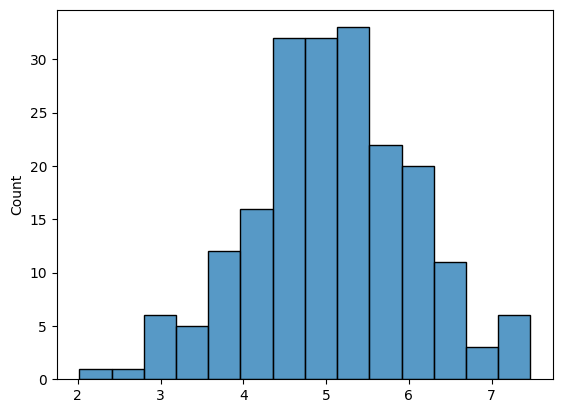

In [3]:
n = 200

mu_0 = 5
sigma2_0 = 1

np.random.seed(10)

y0 = np.random.normal(loc = mu_0, scale = np.sqrt(sigma2_0), size = n)

print("Sample mean: {}".format(np.mean(y0)))
print("Sample variance: {}".format(np.var(y0, ddof = 1)))

sns.histplot(x = y0)
plt.show()

In [4]:
regression0_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 1, "init": np.mean(y0)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": np.var(y0)}
}

def regression0_loglikelihood_loss(model, nn_output, data):
    X, y = data

    mu = model.get_variable("mu")
    sigma2 = model.get_variable("sigma2")

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    
    return -loglik

In [5]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression0_model = thf.ModelNN(regression0_parameters, regression0_loglikelihood_loss,
                                    None, None, None,
                                    input_dim = (None, 1), seed = 10)
    
    data0 = [y0]
    
    regression0_mu_before_pretrain = regression0_model.predict("mu")
    regression0_sigma2_before_pretrain = regression0_model.predict("sigma2")
    
    regression0_model.train_model(epochs = 5000, x = None, data = data0,
                                  shuffle = True,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_warmup = 10,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                                  deterministic = True,
                                  verbose = 1)
    
    regression0_mu_after_train = regression0_model.predict("mu")
    regression0_sigma2_after_train = regression0_model.predict("sigma2")

Global seed set to 10.
Initializing training...

Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 5.418 seconds.


In [6]:
df_summary0 = regression0_model.summary()
df_summary0

,index,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,5.074307,0.069031,4.939009,5.209605,0.953051,0.095305,0.783423,1.159408


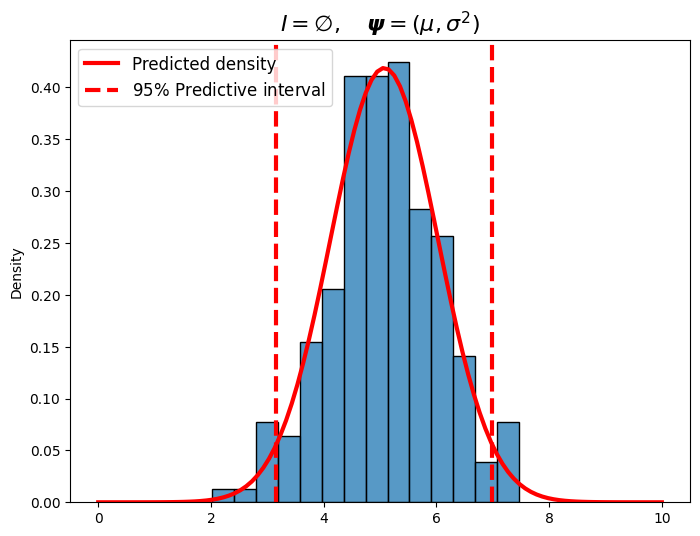

In [7]:
xs = np.linspace(0, 10, 100)

alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var0 = df_summary0["mu_se"]**2 + df_summary0["sigma2"]
y_new_lower0 = df_summary0["mu"] - z_norm * np.sqrt(y_new_var0)
y_new_upper0 = df_summary0["mu"] + z_norm * np.sqrt(y_new_var0)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.histplot(x = y0, stat = "density", ax = ax)
sns.lineplot(x = xs, y = norm.pdf(xs, loc = regression0_mu_after_train, scale = regression0_sigma2_after_train), color = "red", linewidth = 3, ax = ax, label = "Predicted density")
ax.axvline(y_new_lower0[0], color = "red", linewidth = 3, linestyle = "dashed", label = r"$95\%$ Predictive interval")
ax.axvline(y_new_upper0[0], color = "red", linewidth = 3, linestyle = "dashed")

sort_sigma2_0 = sigma2_0
y_new_lower0_true = df_summary0["mu"] - z_norm * np.sqrt( df_summary0["mu_se"]**2 + sort_sigma2_0 )
y_new_upper0_true = df_summary0["mu"] + z_norm * np.sqrt( df_summary0["mu_se"]**2 + sort_sigma2_0 )

# ax.axvline(y_new_lower0_true[0], color = "green", linewidth = 3, linestyle = "dashed", label = r"True $\sigma^2$ 95% CI")
# ax.axvline(y_new_upper0_true[0], color = "green", linewidth = 3, linestyle = "dashed")
ax.legend(fontsize = 16)
ax.set_title(r"$I = \emptyset, \quad \boldsymbol{\psi} = (\mu, \sigma^2)$", fontsize = 16)
ax.legend(loc = "upper left", fontsize = 12)

plt.show()

# Homoscedastic Neural Model

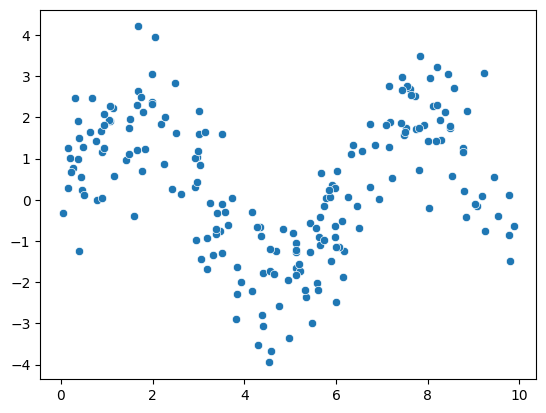

In [8]:
n = 200

sigma2_1 = 1

np.random.seed(10)
x1 = np.random.uniform(low = 0.0, high = 10.0, size = n)

true_f1 = lambda x : 2*np.sin(x)
y1 = true_f1(x1) + np.random.normal(loc = 0.0, scale = np.sqrt(sigma2_1), size = n)

sns.scatterplot(x = x1, y = y1)
plt.show()

In [9]:
regression1_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": np.mean(y1)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": np.var(y1)}
}

def regression1_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2")
    # Simply replaces the linear predictor by the nn_output
    mu = model.get_variable("mu", nn_output)

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

def regression1_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 16, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense3")
    model.dense4 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression1_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return model.dense4(x)

def regression1_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return x

In [10]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression1_model = thf.ModelNN(regression1_parameters, regression1_loglikelihood_loss,
                                      regression1_neural_network, regression1_network_call,
                                      regression1_network_call_nolast, input_dim = (None, 1), seed = 10)

    x1_scaled = (x1 - np.mean(x1)) / np.std(x1, ddof = 1)
    data1 = [y1]
    
    sort_x1 = np.sort(x1)
    sort_x1_scaled = (sort_x1 - np.mean(sort_x1)) / np.std(sort_x1, ddof = 1)
    
    regression1_mu_before_pretrain = regression1_model.predict(sort_x1_scaled)["mu"].numpy().flatten()
    regression1_sigma2_before_pretrain = regression1_model.predict("sigma2")
    
    regression1_model.pre_train_model(epochs = 500, x = x1_scaled, data = data1,
                                      shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = True, track_time = True)
    
    regression1_mu_after_pretrain = regression1_model.predict(sort_x1_scaled)["mu"].numpy().flatten()
    regression1_sigma2_after_pretrain = regression1_model.predict("sigma2")
    
    regression1_model.train_model(epochs = 15000, x = x1_scaled, data = data1,
                                  shuffle = True,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.1),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.1),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 5,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                                  verbose = 1, print_freq = 50)
    
    regression1_mu_after_train = regression1_model.predict(sort_x1_scaled)["mu"].numpy().flatten()
    regression1_sigma2_after_train = regression1_model.predict("sigma2")

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 150 / 15000 ]  | Loss:  99.2050476 | Best Loss:  96.3983154 | Speed:  1265  epoch/s    | Elapsed Time:  0.118487597  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 100 / 15000 ]  | Loss:  92.5250397 | Best Loss:  92.5250397 | Speed:  1898  epoch/s    | Elapsed Time:  0.0526838303  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 3.194 seconds.


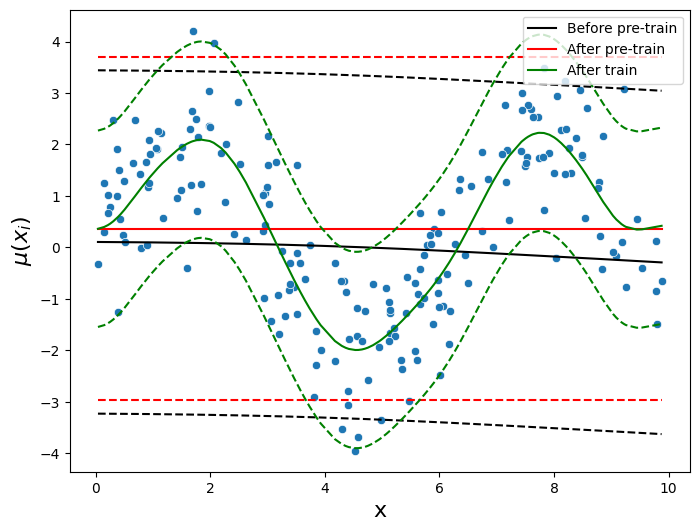

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x1, y = y1)

sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain, ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain - 2*np.sqrt(regression1_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_before_pretrain + 2*np.sqrt(regression1_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain, ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain - 2*np.sqrt(regression1_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_after_pretrain + 2*np.sqrt(regression1_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x1, y = regression1_mu_after_train, ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x1, y = regression1_mu_after_train - 2*np.sqrt(regression1_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x1, y = regression1_mu_after_train + 2*np.sqrt(regression1_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [12]:
sort_x1 = np.sort(x1)

df_summary1 = regression1_model.summary(sort_x1_scaled[:,None])
df_summary1.insert(1, "x", sort_x1_scaled)
df_summary1

,index,x,sigma2,sigma2_se,sigma2_lower,sigma2_upper,mu,mu_se,mu_lower,mu_upper
0,1,-1.699736,0.910035,0.091019,0.748038,1.107115,0.361932,0.190157,-0.010768,0.734632
1,2,-1.660932,0.910035,0.091019,0.748038,1.107115,0.396303,0.185505,0.032721,0.759886
2,3,-1.660115,0.910035,0.091019,0.748038,1.107115,0.397354,0.185354,0.034068,0.760640
3,4,-1.638720,0.910035,0.091019,0.748038,1.107115,0.429941,0.180572,0.076026,0.783856
4,5,-1.637220,0.910035,0.091019,0.748038,1.107115,0.432599,0.180177,0.079459,0.785739
...,...,...,...,...,...,...,...,...,...,...
195,196,1.747786,0.910035,0.091019,0.748038,1.107115,0.350473,0.190542,-0.022983,0.723930
196,197,1.833797,0.910035,0.091019,0.748038,1.107115,0.396754,0.184688,0.034771,0.758736
197,198,1.836769,0.910035,0.091019,0.748038,1.107115,0.398603,0.184471,0.037046,0.760161
198,199,1.840109,0.910035,0.091019,0.748038,1.107115,0.400672,0.184230,0.039587,0.761757


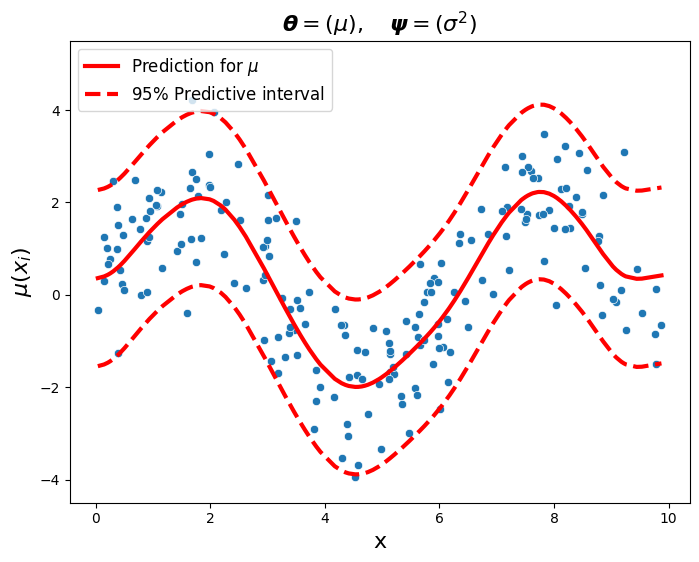

In [13]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var1 = df_summary1["mu_se"]**2 + df_summary1["sigma2"]
y_new_lower1 = df_summary1["mu"] - z_norm * np.sqrt(y_new_var1)
y_new_upper1 = df_summary1["mu"] + z_norm * np.sqrt(y_new_var1)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x1, y = y1)
sns.lineplot(x = sort_x1, y = df_summary1["mu"], color = "red", ax = ax, linewidth = 3, label = r"Prediction for $\mu$")
sns.lineplot(x = sort_x1, y = y_new_lower1, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"$95\%$ Predictive interval")
sns.lineplot(x = sort_x1, y = y_new_upper1, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_1 = sigma2_1
y_new_lower1_true = df_summary1["mu"] - z_norm * np.sqrt( df_summary1["mu_se"]**2 + sort_sigma2_1 )
y_new_upper1_true = df_summary1["mu"] + z_norm * np.sqrt( df_summary1["mu_se"]**2 + sort_sigma2_1 )

# sns.lineplot(x = sort_x2, y = y_new_lower2_true, color = "purple", linestyle = "dashed", ax = ax)
# sns.lineplot(x = sort_x2, y = y_new_upper2_true, color = "purple", linestyle = "dashed", ax = ax)
# sns.lineplot(x = sort_x1, y = y_new_lower1_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
# sns.lineplot(x = sort_x1, y = y_new_upper1_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\theta} = (\mu), \quad \boldsymbol{\psi} = (\sigma^2)$", fontsize = 16)
ax.legend(loc = "upper left", fontsize = 12)
ax.set_ylim(-4.5, 5.5)

plt.show()

Just to exemplify the method variable_function_covariance as a general way of obtaining the covariance structure of any function of the parameters, we consider the transformation
\begin{equation*}
f(\mu, \sigma^2) = [\mu, 2\sigma^2]
\end{equation*}
Of course, we expect to see a $2 \times 2$ covariance matrix whose diagonal is equivalent to $\text{Var}[\widehat{\mu}]$ and $4\text{Var}[\widehat{\sigma}^2]$.

In [14]:
# def fun(model, nn_output, data):
#     X, y = data
#     mu = model.get_variable("mu", nn_output)
#     sigma2 = model.get_variable("sigma2")
#     return tf.concat([mu, 2*tf.tile(sigma2[:,None], (tf.size(mu), 1))], axis = -1)

# fun_cov = regression1_model.variable_function_covariance(fun, sort_x1[:5], data1)
# fun_cov

In [15]:
# theta_cov = regression1_model.covariance_output(sort_x1[:5])
# theta_cov

In [16]:
# theta_cov[:,0,0]*4

Indeed, we can see that the variances match exactly to their expected values.

# Heteroscedastic linear model

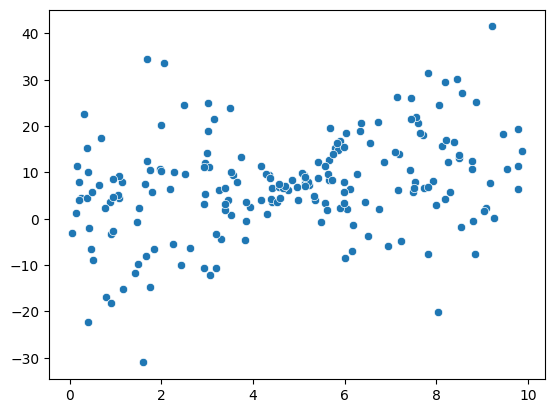

In [24]:
n = 200

np.random.seed(10)
x2 = np.random.uniform(low = 0.0, high = 10.0, size = n)

beta0 = 1
beta1 = 1.2
mu = beta0 + beta1 * x2

def true_sigma2_2(x):
    a = 100
    y = a*np.sin(x) + a + 0.5
    return y

sigma2_2 = true_sigma2_2(x2)

y2 = mu + np.random.normal(loc = 0, scale = np.sqrt(sigma2_2))

sns.scatterplot(x = x2, y = y2)
plt.show()

In [25]:
regression2_parameters = {
    "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 2, "init": 1.0},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0}
}

def regression2_loglikelihood_loss(model, nn_output, data):
    # x, scaled version for sigma2, z is the unscaled version for x
    x, z, y = data
    
    sigma2 = model.get_variable("sigma2", nn_output)
    beta = model.get_variable("beta")
    mu = beta[0] + beta[1] * z
    
    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

def regression2_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 16, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense3")
    model.dense4 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression2_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return model.dense4(x)

def regression2_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return x

In [26]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression2_model = thf.ModelNN(regression2_parameters, regression2_loglikelihood_loss,
                                    regression2_neural_network, regression2_network_call,
                                    regression2_network_call_nolast, input_dim = (None, 1), seed = 10)

    # z2 represents here an unscaled version of x2
    z2 = x2
    data2 = [z2, y2]
    x2_scaled = (x2 - np.mean(x2)) / np.std(x2, ddof = 1)
    sort_x2 = np.sort(x2)
    sort_x2_scaled = (sort_x2 - np.mean(sort_x2)) / np.std(sort_x2, ddof = 1)
    
    regression2_beta_before_pretrain = regression2_model.predict("beta")
    regression2_mu_before_pretrain = regression2_beta_before_pretrain[0] + regression2_beta_before_pretrain[1] * sort_x2
    regression2_sigma2_before_pretrain = regression2_model.predict(sort_x2_scaled)["sigma2"].numpy().flatten()
    
    regression2_model.pre_train_model(epochs = 500, x = x2_scaled, data = data2,
                                      shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                      optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = True, track_time = True)
    
    regression2_beta_after_pretrain = regression2_model.predict("beta")
    regression2_mu_after_pretrain = regression2_beta_after_pretrain[0] + regression2_beta_after_pretrain[1] * sort_x2
    regression2_sigma2_after_pretrain = regression2_model.predict(sort_x2_scaled)["sigma2"].numpy().flatten()
    
    regression2_model.train_model(epochs = 15000, x = x2_scaled, data = data2,
                                  shuffle = True,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_warmup = 100,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 5,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                                  verbose = 1, print_freq = 50)
    
    regression2_beta_after_train = regression2_model.predict("beta")
    regression2_mu_after_train = regression2_beta_after_train[0] + regression2_beta_after_train[1] * sort_x2
    regression2_sigma2_after_train = regression2_model.predict(sort_x2_scaled)["sigma2"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 850 / 15000 ]  | Loss:  519.202576 | Best Loss:  519.202576 | Speed:  1152  epoch/s    | Elapsed Time:  0.737526178  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 150 / 15000 ]  | Loss:  519.173096 | Best Loss:  519.173096 | Speed:  1631  epoch/s    | Elapsed Time:  0.091930151  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 4.356 seconds.


In [27]:
df_summary2 = regression2_model.summary(sort_x2_scaled[:,None])
df_summary2.insert(1, "x", sort_x2_scaled)
df_summary2

,index,x,beta[0],beta[0]_se,beta[0]_lower,beta[0]_upper,beta[1],beta[1]_se,beta[1]_lower,beta[1]_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,-1.699736,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,85.762550,14.108974,62.124760,118.394257
1,2,-1.660932,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,90.835121,14.597620,66.292107,124.464600
2,3,-1.660115,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,90.946945,14.609032,66.383110,124.600166
3,4,-1.638720,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,93.946152,14.925308,68.809402,128.265594
4,5,-1.637220,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,94.161827,14.948809,68.982834,128.531265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,1.747786,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,95.760612,35.223137,46.568676,196.915543
196,197,1.833797,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,83.528435,35.733582,36.115131,193.187729
197,198,1.836769,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,83.117020,35.737373,35.785202,193.052994
198,199,1.840109,0.964071,1.370543,-1.722145,3.650287,1.259715,0.274091,0.722507,1.796924,82.655586,35.740486,35.416893,192.900787


In [28]:
def linear_mu(model, nn_output, data):
    x, z, y = data
    beta = model.get_variable("beta")
    mu = beta[0] + beta[1] * z
    return mu

mu_covariances = regression2_model.variable_function_covariance(fun = linear_mu, data = data2, x = sort_x2)
# Take the diagonal od the matrices
mu_variances = np.diagonal(mu_covariances, axis1 = 1, axis2 = 2).flatten()
mu_se = np.sqrt(mu_variances)

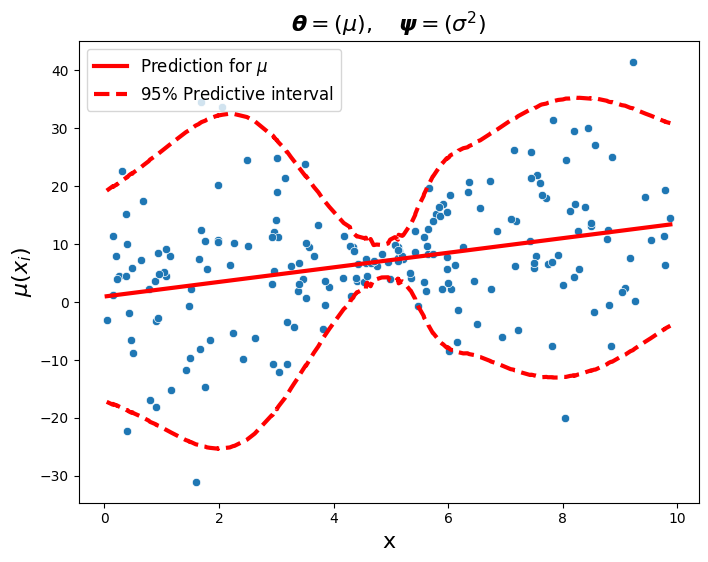

In [29]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var2 = mu_se**2 + df_summary2["sigma2"]
y_new_lower2 = regression2_mu_after_train - z_norm * np.sqrt(y_new_var2)
y_new_upper2 = regression2_mu_after_train + z_norm * np.sqrt(y_new_var2)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x2, y = y2)
sns.lineplot(x = sort_x2, y = regression2_mu_after_train, color = "red", ax = ax, linewidth = 3, label = r"Prediction for $\mu$")
sns.lineplot(x = sort_x2, y = y_new_lower2, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"$95\%$ Predictive interval")
sns.lineplot(x = sort_x2, y = y_new_upper2, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

# sort_sigma2_2 = true_sigma2_2(sort_x2)
# y_true_var2 = mu_se**2 + sort_sigma2_2
# y_true_lower2 = regression2_mu_after_train - z_norm * np.sqrt(y_true_var2)
# y_true_upper2 = regression2_mu_after_train + z_norm * np.sqrt(y_true_var2)
# sns.lineplot(x = sort_x2, y = y_true_lower2, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"$95\%$ True predictive interval")
# sns.lineplot(x = sort_x2, y = y_true_upper2, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\theta} = (\mu), \quad \boldsymbol{\psi} = (\sigma^2)$", fontsize = 16)
ax.legend(loc = "upper left", fontsize = 12)
# ax.set_ylim(-4.5, 5.5)

plt.show()

# Heretoscedastic fully flexible regression model

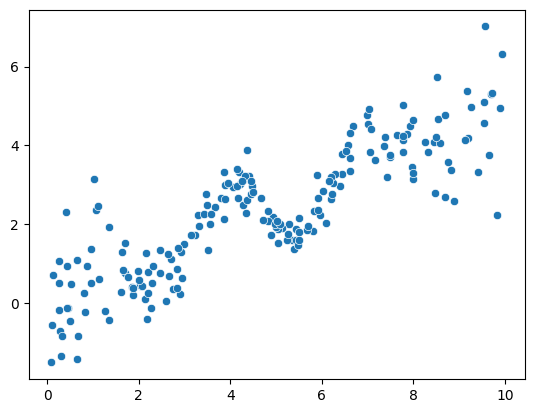

In [96]:
n = 200

np.random.seed(2)
x3 = np.random.uniform(low = 0.0, high = 10.0, size = n)

true_mu_3 = lambda x : 1 / (1 + np.exp(-x))
def true_mu_3(x):
    return 0.5*x + np.sin(2*x) * np.exp( -0.1 * (x-5)**2 )

def true_mu_3(x):
    return 0.5*x + np.sin(2*x) * np.exp(-0.1*(x-5)**2)
    
def true_sigma2_3(x):
    k = 0.05
    return k*(x-5)**2 + 0.05

mu_3 = true_mu_3(x3)
sigma2_3 = true_sigma2_3(x3)

y3 = mu_3 + np.random.normal(loc = 0, scale = np.sqrt(sigma2_3))

sns.scatterplot(x = x3, y = y3)
plt.show()

In [97]:
regression3_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": np.mean(y3)},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": np.var(y3)}
}

def regression3_loglikelihood_loss(model, nn_output, data):
    X, y = data
    
    sigma2 = model.get_variable("sigma2", nn_output)
    mu = model.get_variable("mu", nn_output)

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )

    return -loglik

def regression3_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 16, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense3")
    model.dense4 = keras.layers.Dense(units = 2, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression3_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return model.dense4(x)

def regression3_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return x

In [98]:
with tf.device("/CPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    regression3_model = thf.ModelNN(regression3_parameters, regression3_loglikelihood_loss,
                                    regression3_neural_network, regression3_network_call,
                                    regression3_network_call_nolast, input_dim = (None, 1), seed = 10)
    
    # Remove the column of ones (already handled by tensorflow)
    data3 = [y3]
    sort_x3 = np.sort(x3)
    
    regression3_mu_before_pretrain = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_before_pretrain = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()
    
    regression3_model.pre_train_model(epochs = 500, x = x3, data = data3,
                                      shuffle = True,
                                      validation = False, val_prop = 0.2,
                                      optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                      optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = 4096, gradient_accumulation_steps = None,
                                      early_stopping = True, early_stopping_warmup = 100,
                                      reduce_lr = True, reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10, reduce_lr_cooldown = 0,
                                      reduce_lr_min_lr = 1e-4,
                                      deterministic = True,
                                      verbose = True, track_time = True)
    
    regression3_mu_after_pretrain = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_after_pretrain = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()

    regression3_model.train_model(epochs = 15000, x = x3, data = data3,
                                  shuffle = True,
                                  validation = False, val_prop = 0.2,
                                  optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                  optimizer_nn = optimizers.RMSprop(learning_rate = 0.01),
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = 4096, gradient_accumulation_steps = None,
                                  early_stopping = True, early_stopping_warmup = 500,
                                  reduce_lr = True, reduce_lr_warmup = 10,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.5, reduce_lr_patience = 10,
                                  reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                                  deterministic = True,
                                  verbose = 1, print_freq = 50)

    regression3_mu_after_train = regression3_model.predict(sort_x3)["mu"].numpy().flatten()
    regression3_sigma2_after_train = regression3_model.predict(sort_x3)["sigma2"].numpy().flatten()

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 500 / 15000 ]  | Loss:  7.49453545 | Best Loss:  7.49453545 | Speed:  1411  epoch/s    | Elapsed Time:  0.354332447  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 500 / 15000 ]  | Loss:  -6.25747204 | Best Loss:  -6.25747204 | Speed:  2038  epoch/s    | Elapsed Time:  0.245238781  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 4.148 seconds.


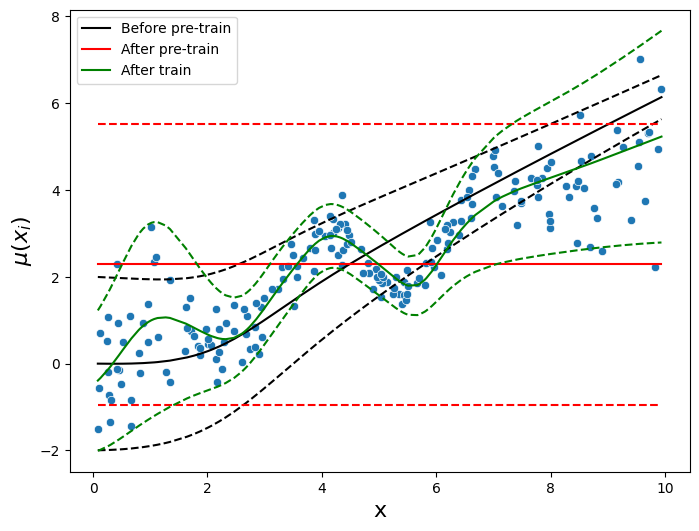

In [99]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x3, y = y3)

sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain, ax = ax, label = "Before pre-train", color = "black")
sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain - 2*np.sqrt(regression3_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_before_pretrain + 2*np.sqrt(regression3_sigma2_before_pretrain), ax = ax, color = "black", linestyle = "dashed")

sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain, ax = ax, label = "After pre-train", color = "red")
sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain - 2*np.sqrt(regression3_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_after_pretrain + 2*np.sqrt(regression3_sigma2_after_pretrain), ax = ax, color = "red", linestyle = "dashed")

sns.lineplot(x = sort_x3, y = regression3_mu_after_train, ax = ax, label = "After train", color = "green")
sns.lineplot(x = sort_x3, y = regression3_mu_after_train - 2*np.sqrt(regression3_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")
sns.lineplot(x = sort_x3, y = regression3_mu_after_train + 2*np.sqrt(regression3_sigma2_after_train), ax = ax, color = "green", linestyle = "dashed")

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)

plt.show()

In [100]:
df_summary3 = regression3_model.summary(sort_x3[:,None])
df_summary3.insert(1, "x", sort_x3)
df_summary3

,index,x,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,0.084484,-0.391971,0.141449,-0.669206,-0.114736,0.653628,0.199655,0.359191,1.189423
1,2,0.102500,-0.369289,0.141473,-0.646572,-0.092006,0.665199,0.200041,0.368957,1.199300
2,3,0.130173,-0.333061,0.141626,-0.610643,-0.055478,0.683495,0.200671,0.384438,1.215192
3,4,0.252014,-0.154519,0.144124,-0.436996,0.127958,0.771909,0.205092,0.458570,1.299349
4,5,0.255509,-0.148973,0.144241,-0.431681,0.133735,0.774635,0.205288,0.460807,1.302195
...,...,...,...,...,...,...,...,...,...,...
195,196,9.705803,5.114118,0.169490,4.781923,5.446312,1.369816,0.361155,0.817036,2.296589
196,197,9.729107,5.125892,0.170164,4.792377,5.459407,1.381303,0.365964,0.821809,2.321705
197,198,9.831534,5.177637,0.173130,4.838309,5.516964,1.432958,0.387823,0.843062,2.435607
198,199,9.885097,5.204687,0.174684,4.862313,5.547061,1.460737,0.399734,0.854355,2.497500


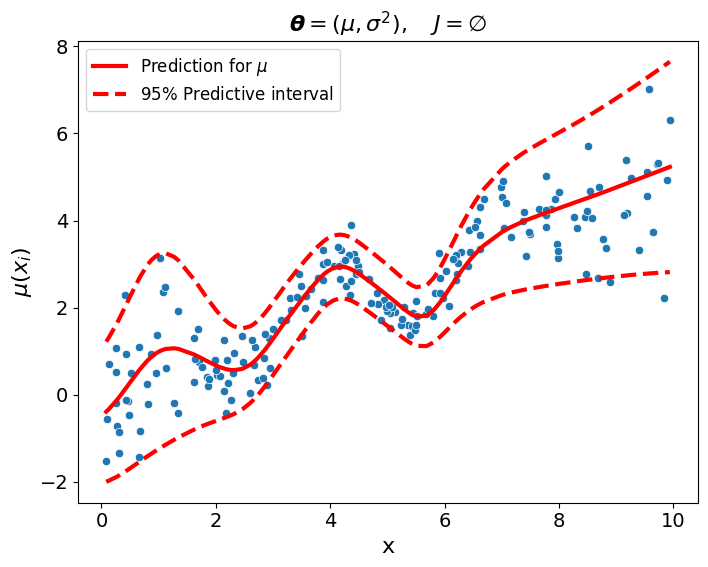

In [106]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
y_new_var3 = df_summary3["mu_se"]**2 + df_summary3["sigma2"]
y_new_lower3 = df_summary3["mu"] - z_norm * np.sqrt(y_new_var3)
y_new_upper3 = df_summary3["mu"] + z_norm * np.sqrt(y_new_var3)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x3, y = y3)
sns.lineplot(x = sort_x3, y = df_summary3["mu"], color = "red", ax = ax, linewidth = 3, label = r"Prediction for $\mu$")
sns.lineplot(x = sort_x3, y = y_new_lower3, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"$95\%$ Predictive interval")
sns.lineplot(x = sort_x3, y = y_new_upper3, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

sort_sigma2_3 = true_sigma2_3(sort_x3)
y_new_lower3_true = df_summary3["mu"] - z_norm * np.sqrt( df_summary3["mu_se"]**2 + sort_sigma2_3 )
y_new_upper3_true = df_summary3["mu"] + z_norm * np.sqrt( df_summary3["mu_se"]**2 + sort_sigma2_3 )

# sns.lineplot(x = sort_x3, y = y_new_lower3_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3, label = r"True $\sigma^2$ 95% CI")
# sns.lineplot(x = sort_x3, y = y_new_upper3_true, color = "green", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"$\boldsymbol{\theta} = (\mu, \sigma^2), \quad J = \emptyset$", fontsize = 16)
ax.legend(loc = "upper left", fontsize = 12)

plt.show()

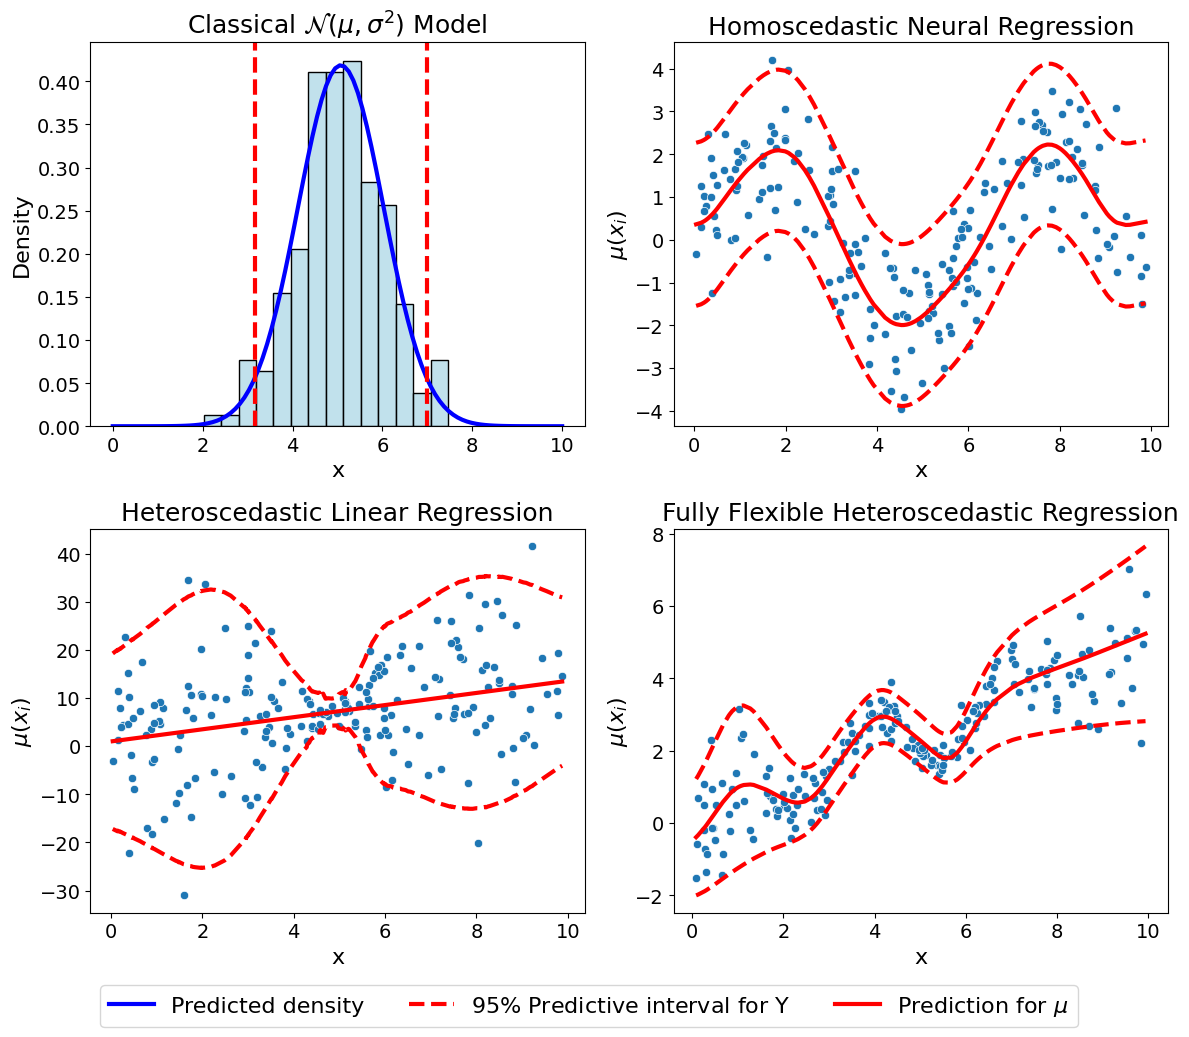

In [110]:
# 1. Update global matplotlib parameters for publication-quality sizing
plt.rcParams.update({
    "font.size": 14,            # General font size
    "axes.titlesize": 18,       # Subplot title size
    "axes.labelsize": 16,       # X and Y label size
    "xtick.labelsize": 14,      # X tick labels (numbers on axis)
    "ytick.labelsize": 14,      # Y tick labels (numbers on axis)
    "legend.fontsize": 16,      # Legend text size
    "figure.titlesize": 20      # Main figure title size (if used)
})

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,10))

sns.histplot(x = y0, stat = "density", ax = ax[0,0], color = "lightblue")
sns.lineplot(x = xs, y = norm.pdf(xs, loc = regression0_mu_after_train, scale = regression0_sigma2_after_train), color = "blue", linewidth = 3, ax = ax[0,0], label = "Predicted density")
ax[0,0].axvline(y_new_lower0[0], color = "red", linewidth = 3, linestyle = "dashed", label = r"$95\%$ Predictive interval for Y")
ax[0,0].axvline(y_new_upper0[0], color = "red", linewidth = 3, linestyle = "dashed")

sns.scatterplot(x = x1, y = y1, ax = ax[0,1])
sns.lineplot(x = sort_x1, y = df_summary1["mu"], color = "red", ax = ax[0,1], linewidth = 3, label = r"Prediction for $\mu$")
sns.lineplot(x = sort_x1, y = y_new_lower1, color = "red", linestyle = "dashed", ax = ax[0,1], linewidth = 3, label = r"$95\%$ Predictive interval for Y")
sns.lineplot(x = sort_x1, y = y_new_upper1, color = "red", linestyle = "dashed", ax = ax[0,1], linewidth = 3)

sns.scatterplot(x = x2, y = y2, ax = ax[1,0])
sns.lineplot(x = sort_x2, y = regression2_mu_after_train, color = "red", ax = ax[1,0], linewidth = 3, label = r"Prediction for $\mu$")
sns.lineplot(x = sort_x2, y = y_new_lower2, color = "red", linestyle = "dashed", ax = ax[1,0], linewidth = 3, label = r"$95\%$ Predictive interval for Y")
sns.lineplot(x = sort_x2, y = y_new_upper2, color = "red", linestyle = "dashed", ax = ax[1,0], linewidth = 3)

sns.scatterplot(x = x3, y = y3, ax = ax[1,1])
sns.lineplot(x = sort_x3, y = df_summary3["mu"], color = "red", ax = ax[1,1], linewidth = 3, label = r"Prediction for $\mu$")
sns.lineplot(x = sort_x3, y = y_new_lower3, color = "red", linestyle = "dashed", ax = ax[1,1], linewidth = 3, label = r"$95\%$ Predictive interval for Y")
sns.lineplot(x = sort_x3, y = y_new_upper3, color = "red", linestyle = "dashed", ax = ax[1,1], linewidth = 3)

# Set labels and titles (REMOVED all ax[...].legend() calls)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("Density")
ax[0,0].set_title(r"Classical $\mathcal{N}(\mu, \sigma^2)$ Model")

ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel(r"$\mu(x_i)$")
ax[0,1].set_title(r"Homoscedastic Neural Regression")

ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel(r"$\mu(x_i)$")
ax[1,0].set_title(r"Heteroscedastic Linear Regression")

ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel(r"$\mu(x_i)$")
ax[1,1].set_title(r"Fully Flexible Heteroscedastic Regression")

# --- NEW: Extract unique labels and handles for the global legend ---
handles, labels = [], []
for a in ax.flat:
    # Get handles and labels from each subplot
    h, l = a.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:  # Only add unique items
            handles.append(handle)
            labels.append(label)
    
    # Seaborn automatically adds legends sometimes; this removes them from subplots
    if a.get_legend():
        a.get_legend().remove()

# --- NEW: Add the single global legend ---
# bbox_to_anchor pulls the legend down below the plots. ncol=3 spreads them horizontally.
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))

# Adjust layout so subplots don't overlap with each other
plt.tight_layout()

# --- NEW: Save High Quality Figures (MUST be before plt.show()) ---
# Vector graphic (Best for papers/LaTeX)
plt.savefig("normal_distribution_examples.pdf", format="pdf", bbox_inches="tight") 

# Raster graphic fallback (300 DPI is standard publication minimum)
plt.savefig("normal_distribution_examples.png", dpi=300, bbox_inches="tight")

plt.show()